![image.png](attachment:image.png)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo.
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [ ]:
import bootcampviztools as bt
import cv2 # opencv

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import random

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from skimage.io import imread

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

from time import time

tf.random.set_seed(42)

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras.



## 1. Carga de datos train y test

In [ ]:
PATH_DATA = "/content/drive/MyDrive/Colab_Notebooks/CNN/data/"

train_files = []
for i in range(4):  # Recorre las carpetas
    train_files += [PATH_DATA + f"github_train_{i}/" + img for img in os.listdir(PATH_DATA + f"github_train_{i}")] # Dirección de las imagenes

test_files = [PATH_DATA + "github_test/" + img for img in os.listdir(PATH_DATA + "github_test")]  # Lo mismo con test

In [ ]:
X_train = np.array([img_to_array(load_img(img, target_size=(32, 32))).astype("uint8") for img in train_files])  # Cargar las imágenes en 32x32 en 8bits (0 a 255)

y_train = np.array([os.path.basename(img).split(".")[0] for img in train_files]) # Basename da el final de la dir (nombre.jpg)

In [ ]:
# Lo mismo con test
X_test = np.array([img_to_array(load_img(img, target_size=(32, 32))).astype("uint8") for img in test_files])

y_test = np.array([os.path.basename(img).split(".")[0] for img in test_files])

In [ ]:
X_train.shape, X_test.shape

((4000, 32, 32, 3), (1000, 32, 32, 3))

## 2.1. Visualización y MiniEDA

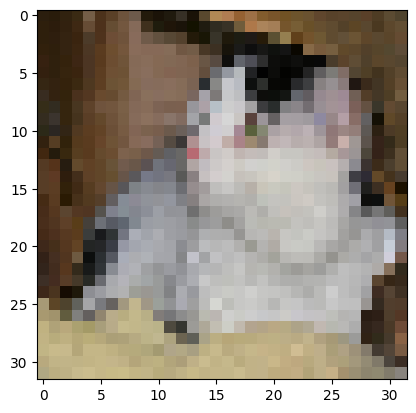

In [ ]:
plt.imshow(X_test[2])

In [ ]:
y_test[2]

np.str_('cat')

In [ ]:
def show_images_batch(pets, names = [], n_cols = 5, size_scale = 2):
    n_rows = ((len(pets) - 1) // n_cols + 1)
    plt.figure(figsize=(n_cols * size_scale, n_rows * 1.1*size_scale))
    for index, pet in enumerate(pets):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(pet, cmap = "Greys")
        plt.axis("off")
        if len(names):
            plt.title(names[index])

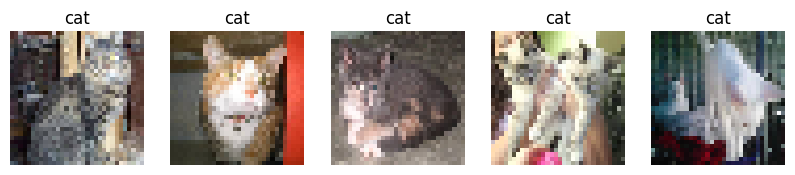

In [ ]:
indices = np.random.randint(100,300,5)
show_images_batch(X_train[indices], names= y_train[indices])  # Las imagenes estan todavia ordenadas

In [ ]:
# Veamos la distribuciónde los datos
pd.Series(y_train).value_counts(True) # Perfectamente equilibrado

,proportion
cat,0.5
dog,0.5


## 2.2. Escalado

In [ ]:
X_train= X_train/255
X_test = X_test/255

In [ ]:
(X_test[0].min(), X_test[0].max()), (X_train[0].min(), X_train[0].max())

((np.float64(0.0), np.float64(1.0)),
 (np.float64(0.0), np.float64(0.8588235294117647)))

## 3. Modelo

### Desordenar los datos
Las imágenes están ordenadas en perros y gatos, hay que desordenarlas.

In [ ]:
from sklearn.utils import shuffle

X_train_shuffled, y_train_shuffled = shuffle(X_train, y_train, random_state = 42)

In [ ]:
print(y_train[:5], y_train_shuffled[:5], end = "\n")

['cat' 'cat' 'cat' 'cat' 'cat'] ['cat' 'dog' 'cat' 'dog' 'dog']


### Diseño del modelo

In [ ]:
model = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),

    keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    keras.layers.MaxPooling2D((2, 2), padding="same"),
    keras.layers.Dropout(0.25), # Dropout 1

    keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    keras.layers.MaxPooling2D((2, 2), padding="same"),
    keras.layers.Dropout(0.25), # Dropoput 2

    keras.layers.Flatten(),
    keras.layers.Dense(512, activation="relu"),
    keras.layers.Dropout(0.5),  # Droput 3

    keras.layers.Dense(1, activation="sigmoid") # Resultado binario -> sigmoide
])

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,270,977 (16.29 MB)

 Trainable params: 4,270,977 (16.29 MB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento

In [ ]:
y_train_num = np.array([0 if y == "cat" else 1 for y in y_train_shuffled])  # Pasamos a binario para encajar con el modelo
y_test_num = np.array([0 if y == "cat" else 1 for y in y_test]) # Lo mismo con test

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True) # Recupera los pesos de la mejor época al acabar

In [ ]:
history = model.fit(
    X_train_shuffled,
    y_train_num,
    epochs = 100,
    batch_size = 32,
    callbacks = [early_stopping],
    validation_split = 0.2)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 240ms/step - accuracy: 0.5572 - loss: 0.6959 - val_accuracy: 0.5350 - val_loss: 0.7055
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 48s 314ms/step - accuracy: 0.6381 - loss: 0.6289 - val_accuracy: 0.6775 - val_loss: 0.6084
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 281ms/step - accuracy: 0.6834 - loss: 0.5946 - val_accuracy: 0.6913 - val_loss: 0.5981
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 34s 207ms/step - accuracy: 0.6975 - loss: 0.5696 - val_accuracy: 0.6963 - val_loss: 0.5940
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 237ms/step - accuracy: 0.7272 - loss: 0.5474 - val_accuracy: 0.7125 - val_loss: 0.5775
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 208ms/step - accuracy: 0.7300 - loss: 0.5262 - val_accuracy: 0.7088 - val_loss: 0.5845
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 214ms/step - accuracy: 0.7434 - loss: 0.5064 - val_accuracy: 0.7063 - val_loss: 0.5799
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 225ms/step - accuracy: 0.7622 -

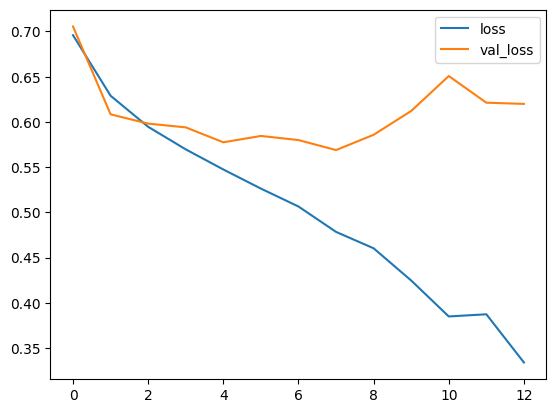

In [ ]:
pd.DataFrame(history.history)[["loss", "val_loss"]].plot()
plt.show()

## 4. Evaluación del modelo

In [ ]:
results = model.evaluate(X_test, y_test_num)  # Nada mal
results

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.7210 - loss: 0.5658


[0.5658449530601501, 0.7210000157356262]

In [ ]:
predictions = model.predict(X_test)

# Como cat es 0, entre 0 y 0,5 será cat y entre 0,5 y 1 será dog
y_pred = ["dog" if prediction[0] > 0.5 else "cat" for prediction in predictions]

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         cat       0.73      0.71      0.72       500
         dog       0.72      0.73      0.72       500

    accuracy                           0.72      1000
   macro avg       0.72      0.72      0.72      1000
weighted avg       0.72      0.72      0.72      1000



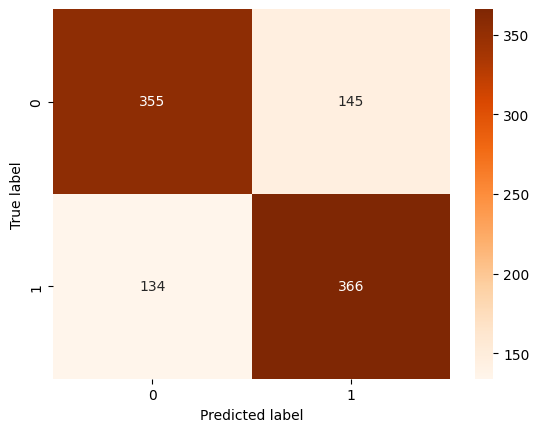

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Oranges")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

Está bastante equilibrado, con un ligero sesgo hacia la predicción de perros, que probablemente se de a causa de algunas fotos reemplazadas por una imagen de un gato en blanco y negro a modo de nulo en imágenes que no estaban disponibles en el momento de descarga. Esto puede haber provovado confusión en el entrenamiento, mezclando perros y gatos.

## 5. Imágenes mal clasificadas

In [ ]:
confianza = [    1 - prediction[0] if prediction[0] <= 0.5 else prediction[0] for prediction in predictions]
df_pred = pd.DataFrame({
    "archivo": [os.path.basename(img) for img in test_files],
    "etiqueta": y_test,
    "prediccion": y_pred,
    "confianza": confianza})

In [ ]:
df_pred

,archivo,etiqueta,prediccion,confianza
0,dog.8533.jpg,dog,cat,0.805526
1,dog.8357.jpg,dog,dog,0.980634
2,cat.12051.jpg,cat,cat,0.849643
3,dog.8507.jpg,dog,cat,0.720966
4,cat.11875.jpg,cat,cat,0.681481
...,...,...,...,...
995,dog.9872.jpg,dog,dog,0.910314
996,dog.9869.jpg,dog,dog,0.979888
997,dog.9884.jpg,dog,cat,0.612645
998,dog.9894.jpg,dog,dog,0.960993


In [ ]:
fallos = df_pred["etiqueta"] != df_pred["prediccion"]

# Sacamos primero las mal clasificadas
cat_fallos = df_pred[(df_pred["etiqueta"] == "cat") & fallos].copy()
dog_fallos = df_pred[(df_pred["etiqueta"] == "dog") & fallos].copy()

In [ ]:
# Ordenar
cat_fallos.sort_values("confianza", ascending=False, inplace=True)
dog_fallos.sort_values("confianza", ascending=False,inplace=True)

In [ ]:
# Gatos
cat_fallos[:int(len(cat_fallos) * 0.1)]

,archivo,etiqueta,prediccion,confianza
272,cat.11793.jpg,cat,dog,0.999023
590,cat.11899.jpg,cat,dog,0.946823
866,cat.11240.jpg,cat,dog,0.925558
817,cat.11462.jpg,cat,dog,0.921862
545,cat.11168.jpg,cat,dog,0.910260
417,cat.11636.jpg,cat,dog,0.900895
792,cat.11288.jpg,cat,dog,0.893939
924,cat.10728.jpg,cat,dog,0.891772
396,cat.10740.jpg,cat,dog,0.889357
842,cat.11739.jpg,cat,dog,0.879698


In [ ]:
# Perros
dog_fallos[:int(len(dog_fallos) * 0.1)]

,archivo,etiqueta,prediccion,confianza
674,dog.8764.jpg,dog,cat,0.995968
502,dog.8696.jpg,dog,cat,0.975555
137,dog.9509.jpg,dog,cat,0.957472
319,dog.9649.jpg,dog,cat,0.929969
657,dog.9346.jpg,dog,cat,0.927297
31,dog.9625.jpg,dog,cat,0.924125
8,dog.8215.jpg,dog,cat,0.922773
990,dog.9876.jpg,dog,cat,0.914863
80,dog.8485.jpg,dog,cat,0.910622
479,dog.8491.jpg,dog,cat,0.904174
